In [6]:
import os
from datasets import load_dataset
from transformers import AutoTokenizer

repo_id = "MrBigBrane/LongBench-v2-32k-CoT"
tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-3B-Instruct")

# Load a generic background corpus to act as the "haystack" padding
print("Downloading background filler corpus (WikiText)...")
wiki = load_dataset("Salesforce/wikitext", "wikitext-2-raw-v1", split="train")
filler_text = "\n".join(wiki["text"])
# Tokenizing the entire wikitext corpus gives us a massive pool of ~2M background tokens
global_filler_tokens = tokenizer.encode(filler_text, add_special_tokens=False)

def process_and_pad_example(example, tok, filler_pool, max_tokens=32700):
    import random # <-- Imported locally for Windows multiprocessing workers
    
    question = example.get("question", "")
    choices = (
        f"A) {example.get('choice_A', '')}\n"
        f"B) {example.get('choice_B', '')}\n"
        f"C) {example.get('choice_C', '')}\n"
        f"D) {example.get('choice_D', '')}"
    )
    target = example.get("answer", "")
    
    header = "Read the following text and answer the multiple-choice question. Let's think step-by-step.\n\nBackground Context:\n"
    footer = f"\n\nQuestion: {question}\n{choices}\n\nAnswer:"
    
    header_tokens = tok.encode(header, add_special_tokens=False)
    footer_tokens = tok.encode(footer, add_special_tokens=False)
    
    raw_context = example.get("context", "")
    context_tokens = tok.encode(raw_context, add_special_tokens=False)
    
    # Calculate how much generic padding is needed to hit exactly 32,700
    current_length = len(header_tokens) + len(context_tokens) + len(footer_tokens)
    padding_needed = max_tokens - current_length
    
    if padding_needed > 0:
        # Grab a random contiguous chunk of background tokens to act as padding
        start_idx = random.randint(0, len(filler_pool) - padding_needed - 1)
        padding_tokens = filler_pool[start_idx : start_idx + padding_needed]
        
        # Prepend the padding so the actual context sits closer to the question
        final_tokens = header_tokens + padding_tokens + context_tokens + footer_tokens
    else:
        # If it's naturally over 32,700, cap it safely
        final_tokens = (header_tokens + context_tokens + footer_tokens)[:max_tokens]
        
    final_prompt = tok.decode(final_tokens)
    
    return {
        "input": final_prompt,
        "outputs": [target],
        "padded_tokens_added": padding_needed if padding_needed > 0 else 0
    }

def filter_short(example, tok):
    # Only keep examples under 30,000 tokens so we can pad them UP
    return len(tok.encode(example["context"], add_special_tokens=False)) < 30000

if __name__ == "__main__":
    num_cpus = max(1, os.cpu_count() - 2)
    print(f"Downloading LongBench-v2...")
    dataset = load_dataset("THUDM/LongBench-v2", split="train")

    print("Filtering dataset for examples under 30k tokens...")
    dataset = dataset.filter(
        filter_short,
        fn_kwargs={"tok": tokenizer},
        num_proc=num_cpus
    )

    print(f"Padding {len(dataset)} examples to exactly 32,700 tokens...")
    formatted = dataset.map(
        process_and_pad_example,
        fn_kwargs={
            "tok": tokenizer, 
            "filler_pool": global_filler_tokens,
            "max_tokens": 32700
        },
        remove_columns=dataset.column_names,
        num_proc=num_cpus
    )

    formatted.push_to_hub(repo_id, split="train")
    print(f"Successfully uploaded {len(formatted)} padded examples to {repo_id}!")

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (2517233 > 131072). Running this sequence through the model will result in indexing errors


Filtering dataset for examples under 30k tokens...
Padding 106 examples to exactly 32,700 tokens...


Map (num_proc=22): 100%|██████████| 106/106 [01:35<00:00,  1.10 examples/s]
Setting num_proc from 1 back to 1 for the train split to disable multiprocessing as it only contains one shard.
Creating parquet from Arrow format: 100%|██████████| 1/1 [00:00<00:00, 11.82ba/s]
Processing Files (1 / 1): 100%|██████████| 7.33MB / 7.33MB,  559kB/s  
New Data Upload: 100%|██████████| 7.33MB / 7.33MB,  559kB/s  
Uploading the dataset shards: 100%|██████████| 1/1 [00:04<00:00,  4.25s/ shards]


Successfully uploaded 106 padded examples to MrBigBrane/LongBench-v2-32k-CoT!


In [8]:
from datasets import load_dataset

# Force a fresh download to overwrite the cached schema
test_dataset = load_dataset(
    "MrBigBrane/LongBench-v2-32k-CoT", 
    split="train",
    download_mode="force_redownload"
)

print(f"Total examples ready for sweep: {len(test_dataset)}")
print(f"Sample prompt length (characters): {len(test_dataset[0]['input'])}")
print(f"Padded tokens added to first example: {test_dataset[0]['padded_tokens_added']}")

Generating train split:   0%|          | 0/106 [00:00<?, ? examples/s]Failed to read file 'C:\Users\theep\.cache\huggingface\hub\datasets--MrBigBrane--LongBench-v2-32k-CoT\snapshots\ace22e6650eb7c499e29d2ced45a93adec6a7061\data\train-00000-of-00001.parquet' with error CastError: Couldn't cast
input: string
outputs: list<element: string>
  child 0, element: string
padded_tokens_added: int64
-- schema metadata --
huggingface: '{"info": {"features": {"input": {"dtype": "string", "_type"' + 154
to
{'input': Value('string'), 'outputs': List(Value('string')), 'original_token_length': Value('int64')}
because column names don't match
Generating train split:   0%|          | 0/106 [00:00<?, ? examples/s]


DatasetGenerationError: An error occurred while generating the dataset

In [10]:
from datasets import load_dataset

# Load the raw Parquet file directly, ignoring any cached repository schema
test_dataset = load_dataset(
    "parquet", 
    data_files="hf://datasets/MrBigBrane/LongBench-v2-32k-CoT/data/train-*", 
    split="train"
)

print(f"Total examples ready for sweep: {len(test_dataset)}")
print(f"Sample prompt length (characters): {len(test_dataset[0]['input'])}")
print(f"Padded tokens added to first example: {test_dataset[0]['padded_tokens_added']}")

Generating train split: 106 examples [00:00, 4704.17 examples/s]

Total examples ready for sweep: 106
Sample prompt length (characters): 135072
Padded tokens added to first example: 8535


In [11]:
from datasets import load_dataset

repo_id = "MrBigBrane/LongBench-v2-32k-CoT"

# 1. Load the parquet file directly to bypass the schema conflict
ds = load_dataset(
    "parquet",
    data_files="hf://datasets/MrBigBrane/LongBench-v2-32k-CoT/data/train-*",
    split="train",
)

# 2. Keep only the exact columns expected by RULER ('input' and 'outputs')
ds = ds.remove_columns([c for c in ds.column_names if c not in ["input", "outputs"]])

# 3. Push to hub under the subset/config name matching your task: 'longbench_v2_cot'
ds.push_to_hub(repo_id, config_name="longbench_v2_cot", split="train")

print("Uploaded successfully under subset 'longbench_v2_cot'!")

Setting num_proc from 1 back to 1 for the train split to disable multiprocessing as it only contains one shard.
Creating parquet from Arrow format: 100%|██████████| 1/1 [00:00<00:00, 16.11ba/s]
Processing Files (1 / 1): 100%|██████████| 7.33MB / 7.33MB,  669kB/s  
New Data Upload: 100%|██████████| 21.3kB / 21.3kB, 2.00kB/s  
Uploading the dataset shards: 100%|██████████| 1/1 [00:01<00:00,  1.43s/ shards]


Uploaded successfully under subset 'longbench_v2_cot'!


In [12]:
import os
from datasets import load_dataset

REPO_ID = "MrBigBrane/LongBench-v2-32k-CoT"
CONFIG_NAME = "longbench_v2_cot"

# Conclude concisely and enforce the exact final extraction string
INSTRUCTION_SUFFIX = (
    "\n\nKeep your reasoning concise (under 3 sentences). "
    "On the final line, provide your answer in the exact format: 'Final Answer: [A/B/C/D]'."
)

print(f"Loading dataset '{REPO_ID}' (config: {CONFIG_NAME})...")
ds = load_dataset(REPO_ID, CONFIG_NAME)


def append_instruction(example):
  raw_input = example["input"].rstrip()
  example["input"] = raw_input + INSTRUCTION_SUFFIX
  return example


print("Appending concise conclusion instructions...")
updated_ds = ds.map(append_instruction)

# Verification check on the first row
sample_prompt = updated_ds["train"][0]["input"]
print("\n=== VERIFICATION: Last 300 characters of prompt #0 ===")
print(sample_prompt[-300:])
print("=" * 60)

# Push update back to Hugging Face
print(f"\nPushing updated dataset back to '{REPO_ID}'...")
updated_ds.push_to_hub(
    repo_id=REPO_ID,
    config_name=CONFIG_NAME,
    commit_message="Enforce concise reasoning limit and Final Answer string format",
)

print("Dataset successfully updated on Hugging Face Hub!")

Loading dataset 'MrBigBrane/LongBench-v2-32k-CoT' (config: longbench_v2_cot)...
Appending concise conclusion instructions...


Map: 100%|██████████| 106/106 [00:00<00:00, 698.36 examples/s]


=== VERIFICATION: Last 300 characters of prompt #0 ===
 It is the readers' obligation to get the "truth" from the primary narrator.
D) The performative interpretation of language transforms what it interprets.

Answer:

Keep your reasoning concise (under 3 sentences). On the final line, provide your answer in the exact format: 'Final Answer: [A/B/C/D]'.

Pushing updated dataset back to 'MrBigBrane/LongBench-v2-32k-CoT'...



Setting num_proc from 1 back to 1 for the train split to disable multiprocessing as it only contains one shard.
Creating parquet from Arrow format: 100%|██████████| 1/1 [00:00<00:00, 23.67ba/s]
Processing Files (1 / 1): 100%|██████████| 7.34MB / 7.34MB,  604kB/s  
New Data Upload: 100%|██████████| 7.15MB / 7.15MB,  589kB/s  
Uploading the dataset shards: 100%|██████████| 1/1 [00:03<00:00,  3.37s/ shards]


Dataset successfully updated on Hugging Face Hub!


In [1]:
import os
import re
from datasets import load_dataset

REPO_ID = "MrBigBrane/LongBench-v2-32k-CoT"
CONFIG_NAME = "longbench_v2_cot"

# Regex matching the previous suffix so we replace it cleanly without accumulating duplicate instructions
OLD_INSTRUCTION_PATTERN = re.compile(
    r"\n\nKeep your reasoning concise \(under 3 sentences\)\..*?Final Answer:.*$",
    re.DOTALL,
)

# New strict single-choice constraint
NEW_INSTRUCTION_SUFFIX = (
    "\n\nKeep your reasoning concise (under 3 sentences). "
    "There is exactly one correct option. "
    "On the final line, provide your answer in the exact format: "
    "'Final Answer: [X]' where X is a single letter (A, B, C, or D)."
)

print(f"Loading dataset '{REPO_ID}' (config: {CONFIG_NAME})...")
ds = load_dataset(REPO_ID, CONFIG_NAME)


def update_instruction(example):
  raw_input = example["input"].rstrip()
  # Strip existing prompt instruction if present, then append the new one
  cleaned_input = OLD_INSTRUCTION_PATTERN.sub("", raw_input).rstrip()
  example["input"] = cleaned_input + NEW_INSTRUCTION_SUFFIX
  return example


print("Updating prompt instructions with single-choice constraint...")
updated_ds = ds.map(update_instruction)

# Verification check on prompt #0
sample_prompt = updated_ds["train"][0]["input"]
print("\n=== VERIFICATION: Last 350 characters of prompt #0 ===")
print(sample_prompt[-350:])
print("=" * 60)

# Push update back to Hugging Face
print(f"\nPushing updated dataset back to '{REPO_ID}'...")
updated_ds.push_to_hub(
    repo_id=REPO_ID,
    config_name=CONFIG_NAME,
    commit_message="Enforce single-choice constraint on Final Answer format",
)

print("Dataset successfully updated on Hugging Face Hub!")

c:\CondaEnvs\opus-ai\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading dataset 'MrBigBrane/LongBench-v2-32k-CoT' (config: longbench_v2_cot)...


c:\CondaEnvs\opus-ai\lib\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\theep\.cache\huggingface\hub\datasets--MrBigBrane--LongBench-v2-32k-CoT. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Generating train split: 100%|██████████| 106/106 [00:00<00:00, 1821.85 examples/s]


Updating prompt instructions with single-choice constraint...


Map: 100%|██████████| 106/106 [00:00<00:00, 1760.29 examples/s]
Setting num_proc from 1 back to 1 for the train split to disable multiprocessing as it only contains one shard.



=== VERIFICATION: Last 350 characters of prompt #0 ===
gation to get the "truth" from the primary narrator.
D) The performative interpretation of language transforms what it interprets.

Answer:

Keep your reasoning concise (under 3 sentences). There is exactly one correct option. On the final line, provide your answer in the exact format: 'Final Answer: [X]' where X is a single letter (A, B, C, or D).

Pushing updated dataset back to 'MrBigBrane/LongBench-v2-32k-CoT'...


Creating parquet from Arrow format: 100%|██████████| 1/1 [00:00<00:00, 25.89ba/s]
Processing Files (1 / 1): 100%|██████████| 7.36MB / 7.36MB,  600kB/s  
New Data Upload: 100%|██████████| 7.17MB / 7.17MB,  585kB/s  
Uploading the dataset shards: 100%|██████████| 1/1 [00:03<00:00,  3.56s/ shards]


Dataset successfully updated on Hugging Face Hub!


In [ ]:
import numpy as np
from datasets import load_dataset
from transformers import AutoTokenizer

REPO_ID = "MrBigBrane/longbench-v2-short"
CONFIG_NAME = "longbench-short"
TOKENIZER_MODEL = "Qwen/Qwen2.5-7B-Instruct"
TOKENIZER_REVISION = "a09a35458c702b33eeacc393d103063234e8bc28"

print(f"Loading tokenizer '{TOKENIZER_MODEL}'...")
tokenizer = AutoTokenizer.from_pretrained(
    TOKENIZER_MODEL, revision=TOKENIZER_REVISION, trust_remote_code=True
)

print(f"Loading dataset '{REPO_ID}'...")
ds = load_dataset(REPO_ID, CONFIG_NAME, split="train")

token_lengths = []
per_prompt_details = []

print(f"Profiling token lengths across {len(ds)} prompts...\n")

for i, example in enumerate(ds):
  prompt_text = example.get("input", "")

  # Verify using apply_chat_template if your harness wraps inputs as chat
  # If the harness feeds raw text, direct tokenization is used
  tokens = tokenizer.encode(prompt_text, add_special_tokens=False)
  num_tokens = len(tokens)
  token_lengths.append(num_tokens)

  idx = example.get("index", example.get("id", i))
  per_prompt_details.append((idx, num_tokens))

# Sort to identify outliers
per_prompt_details.sort(key=lambda x: x[1])

print(f"{'Prompt Index':<15}{'Token Count':<15}")
print("-" * 30)
for idx, count in per_prompt_details[:5]:
  print(f"{idx:<15}{count:<15}")
if len(per_prompt_details) > 10:
  print(f"{'...':<15}{'...':<15}")
for idx, count in per_prompt_details[-5:]:
  print(f"{idx:<15}{count:<15}")

lengths_arr = np.array(token_lengths)
print("\n" + "=" * 35)
print("       TOKEN LENGTH AUDIT")
print("=" * 35)
print(f"Total Prompts:       {len(token_lengths)}")
print(f"Min Tokens:          {lengths_arr.min()}")
print(f"Max Tokens:          {lengths_arr.max()}")
print(f"Mean Tokens:         {lengths_arr.mean():.1f}")
print(f"Median Tokens:       {np.median(lengths_arr):.1f}")
print(f"Std Deviation:       {lengths_arr.std():.2f}")
print(f"Prompts > 32768:     {(lengths_arr > 32768).sum()}")
print(
    f"Prompts in [32k, 33k]: {((lengths_arr >= 32000) & (lengths_arr <= 33000)).sum()}"
)
print("=" * 35)

Loading tokenizer 'Qwen/Qwen2.5-7B-Instruct'...
Loading dataset 'MrBigBrane/longbench-v2-short'...


Generating train split: 100%|██████████| 180/180 [00:00<00:00, 2161.08 examples/s]


Profiling token lengths across 180 prompts...



[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (806486 > 131072). Running this sequence through the model will result in indexing errors


In [ ]:
from datasets import load_dataset
from transformers import AutoTokenizer

# Load tokenizer for your target base architecture
tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-7B-Instruct")

# Load LongBench-v2 short
raw_dataset = load_dataset("THUDM/LongBench-v2", split="train")
short_subset = raw_dataset.filter(lambda example: example["length"] == "short")

NEW_INSTRUCTION_SUFFIX = (
    "\n\nKeep your reasoning concise (under 3 sentences). "
    "There is exactly one correct option. "
    "On the final line, provide your answer in the exact format: "
    "'Final Answer: [X]' where X is a single letter (A, B, C, or D)."
)

def add_templated_prompt(example):
    user_content = (
        f"{example['context']}\n\n"
        f"Question: {example['question']}\n"
        f"A. {example['choice_A']}\n"
        f"B. {example['choice_B']}\n"
        f"C. {example['choice_C']}\n"
        f"D. {example['choice_D']}"
        f"{NEW_INSTRUCTION_SUFFIX}"
    )
    
    messages = [{"role": "user", "content": user_content}]
    
    # tokenize=False returns raw string with chat tokens appended
    # add_generation_prompt=True appends the assistant start tokens (e.g., <|start_header_id|>assistant<|end_header_id|>)
    templated_str = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )
    
    return {
        "raw_prompt": user_content,
        "templated_prompt": templated_str
    }

formatted_ds = short_subset.map(add_templated_prompt)

# Push to Hub
formatted_ds.push_to_hub("MrBigBrane/longbench-v2-short")

Map: 100%|██████████| 180/180 [00:00<00:00, 820.50 examples/s]
Setting num_proc from 1 back to 1 for the train split to disable multiprocessing as it only contains one shard.
Creating parquet from Arrow format: 100%|██████████| 1/1 [00:00<00:00,  6.72ba/s]
Processing Files (1 / 1): 100%|██████████| 29.1MB / 29.1MB, 1.73MB/s  
New Data Upload: 100%|██████████| 28.8MB / 28.8MB, 1.72MB/s  
Uploading the dataset shards: 100%|██████████| 1/1 [00:08<00:00,  8.99s/ shards]


CommitInfo(commit_url='https://huggingface.co/datasets/MrBigBrane/longbench-v2-short/commit/3f253259aa6b9879f2e7ad30823e7876e18fe634', commit_message='Upload dataset', commit_description='', oid='3f253259aa6b9879f2e7ad30823e7876e18fe634', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/MrBigBrane/longbench-v2-short', endpoint='https://huggingface.co', repo_type='dataset', repo_id='MrBigBrane/longbench-v2-short'), pr_revision=None, pr_num=None)

In [1]:
from datasets import Dataset, load_dataset
from transformers import AutoTokenizer

# 1. Model tokenizer used for formatting chat tokens
# Change to your target model architecture (e.g., Qwen/Qwen2.5-7B-Instruct, etc.)
MODEL_ID = "Qwen/Qwen2.5-7B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

# 2. Load LongBench-v2 and isolate the short tier
raw_ds = load_dataset("THUDM/LongBench-v2", split="train")
short_ds = raw_ds.filter(lambda x: x["length"] == "short")

NEW_INSTRUCTION_SUFFIX = (
    "\n\nKeep your reasoning concise (under 3 sentences). "
    "There is exactly one correct option. "
    "On the final line, provide your answer in the exact format: "
    "'Final Answer: [X]' where X is a single letter (A, B, C, or D)."
)


def process_row(example):
    # Assemble the raw prompt text
    user_content = (
        f"{example['context']}\n\n"
        f"Question: {example['question']}\n"
        f"A. {example['choice_A']}\n"
        f"B. {example['choice_B']}\n"
        f"C. {example['choice_C']}\n"
        f"D. {example['choice_D']}"
        f"{NEW_INSTRUCTION_SUFFIX}"
    )

    # Wrap in standard chat structure and append generation prompt tokens
    chat_prompt = tokenizer.apply_chat_template(
        [{"role": "user", "content": user_content}],
        tokenize=False,
        add_generation_prompt=True,
    )

    return {
        "inputs": chat_prompt,
        "outputs": example["answer"].strip(),  # 'A', 'B', 'C', or 'D'
        "difficulty": example.get("difficulty", "unknown"),
        "domain": example.get("domain", "unknown"),
        "sub_domain": example.get("sub_domain", "unknown"),
    }


# Map and drop all raw intermediate columns
processed_ds = short_ds.map(
    process_row, remove_columns=raw_ds.column_names, desc="Formatting dataset"
)

# 3. Push to Hugging Face
REPO_ID = "MrBigBrane/longbench-v2-short"
processed_ds.push_to_hub(
    repo_id=REPO_ID,
    private=False,
    commit_message="Add formatted inputs/outputs with metadata columns",
)

print(f"Uploaded successfully to: https://huggingface.co/datasets/{REPO_ID}")

c:\CondaEnvs\opus-ai\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


KeyboardInterrupt: 

In [5]:
from huggingface_hub import HfApi

REPO_ID = "MrBigBrane/longbench-v2-short"
api = HfApi()

# 1. List all files currently under the 'data/' directory
files = api.list_repo_files(repo_id=REPO_ID, repo_type="dataset")
data_files = [f for f in files if f.startswith("data/")]

print(f"Found files to copy: {data_files}")

# 2. Duplicate each file to the 'longbench-short/' path
for file_path in data_files:
    new_path = file_path.replace("data/", "longbench-short/", 1)
    
    # Download the source file bytes and upload to the new path
    api.upload_file(
        path_or_fileobj=api.hf_hub_download(repo_id=REPO_ID, filename=file_path, repo_type="dataset"),
        path_in_repo=new_path,
        repo_id=REPO_ID,
        repo_type="dataset",
        commit_message=f"Copy {file_path} to {new_path}"
    )
    print(f"Copied {file_path} -> {new_path}")

print("Done! Check your repository files on Hugging Face.")

Found files to copy: ['data/train-00000-of-00001.parquet']


c:\CondaEnvs\opus-ai\lib\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\theep\.cache\huggingface\hub\datasets--MrBigBrane--longbench-v2-short. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Processing Files (1 / 1): 100%|██████████| 9.71MB / 9.71MB,  940kB/s  
New Data Upload: |          |  0.00B /  0.00B

Copied data/train-00000-of-00001.parquet -> longbench-short/train-00000-of-00001.parquet
Done! Check your repository files on Hugging Face.


In [6]:
from datasets import load_dataset
from transformers import AutoTokenizer

MODEL_ID = "Qwen/Qwen2.5-7B-Instruct"
REVISION = "a09a35458c702b33eeacc393d103063234e8bc28"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_ID, revision=REVISION, trust_remote_code=True
)

# Load raw LongBench-v2
raw_ds = load_dataset("THUDM/LongBench-v2", split="train")
short_ds = raw_ds.filter(lambda x: x["length"] == "short")

NEW_INSTRUCTION_SUFFIX = (
    "\n\nKeep your reasoning concise (under 3 sentences). "
    "There is exactly one correct option. "
    "On the final line, provide your answer in the exact format: "
    "'Final Answer: [X]' where X is a single letter (A, B, C, or D)."
)


def format_row(example):
    user_content = (
        f"{example['context']}\n\n"
        f"Question: {example['question']}\n"
        f"A. {example['choice_A']}\n"
        f"B. {example['choice_B']}\n"
        f"C. {example['choice_C']}\n"
        f"D. {example['choice_D']}"
        f"{NEW_INSTRUCTION_SUFFIX}"
    )

    formatted_input = tokenizer.apply_chat_template(
        [{"role": "user", "content": user_content}],
        tokenize=False,
        add_generation_prompt=True,
    )

    return {
        "domain": example.get("domain", "unknown"),
        "sub_domain": example.get("sub_domain", "unknown"),
        "difficulty": example.get("difficulty", "unknown"),
        "inputs": formatted_input,
        "outputs": example["answer"].strip(),
    }


# Drop all other raw columns
clean_ds = short_ds.map(format_row, remove_columns=raw_ds.column_names)

# Push to default config (updates README.md metadata so the schema matches)
clean_ds.push_to_hub(
    repo_id="MrBigBrane/longbench-v2-short",
    config_name="default",
    split="train",
    commit_message="Update schema to 5 columns and fix README metadata",
)

# Push also under config_name 'longbench-short' so santapp-ruler task resolver finds it
clean_ds.push_to_hub(
    repo_id="MrBigBrane/longbench-v2-short",
    config_name="longbench-short",
    split="train",
    commit_message="Add longbench-short config name",
)

Map: 100%|██████████| 180/180 [00:00<00:00, 872.85 examples/s]
Setting num_proc from 1 back to 1 for the train split to disable multiprocessing as it only contains one shard.
Creating parquet from Arrow format: 100%|██████████| 1/1 [00:00<00:00, 10.53ba/s]
Processing Files (1 / 1): 100%|██████████| 9.71MB / 9.71MB,  932kB/s  
New Data Upload: |          |  0.00B /  0.00B,  0.00B/s  
Uploading the dataset shards: 100%|██████████| 1/1 [00:00<00:00,  1.07 shards/s]
No files have been modified since last commit. Skipping to prevent empty commit.
Setting num_proc from 1 back to 1 for the train split to disable multiprocessing as it only contains one shard.
Creating parquet from Arrow format: 100%|██████████| 1/1 [00:00<00:00, 11.88ba/s]
Processing Files (1 / 1): 100%|██████████| 9.71MB / 9.71MB,  939kB/s  
New Data Upload: |          |  0.00B /  0.00B,  0.00B/s  
Uploading the dataset shards: 100%|██████████| 1/1 [00:00<00:00,  1.22 shards/s]


CommitInfo(commit_url='https://huggingface.co/datasets/MrBigBrane/longbench-v2-short/commit/3505e941f7332d0bf9cdb9b444daaa452909efd0', commit_message='Add longbench-short config name', commit_description='', oid='3505e941f7332d0bf9cdb9b444daaa452909efd0', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/MrBigBrane/longbench-v2-short', endpoint='https://huggingface.co', repo_type='dataset', repo_id='MrBigBrane/longbench-v2-short'), pr_revision=None, pr_num=None)

In [7]:
from datasets import load_dataset
from transformers import AutoTokenizer

MODEL_ID = "Qwen/Qwen2.5-7B-Instruct"
REVISION = "a09a35458c702b33eeacc393d103063234e8bc28"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_ID, revision=REVISION, trust_remote_code=True
)

raw_ds = load_dataset("THUDM/LongBench-v2", split="train")
short_ds = raw_ds.filter(lambda x: x["length"] == "short")

NEW_INSTRUCTION_SUFFIX = (
    "\n\nKeep your reasoning concise (under 3 sentences). "
    "There is exactly one correct option. "
    "On the final line, provide your answer in the exact format: "
    "'Final Answer: [X]' where X is a single letter (A, B, C, or D)."
)


def format_row(example):
    user_content = (
        f"{example['context']}\n\n"
        f"Question: {example['question']}\n"
        f"A. {example['choice_A']}\n"
        f"B. {example['choice_B']}\n"
        f"C. {example['choice_C']}\n"
        f"D. {example['choice_D']}"
        f"{NEW_INSTRUCTION_SUFFIX}"
    )

    formatted_input = tokenizer.apply_chat_template(
        [{"role": "user", "content": user_content}],
        tokenize=False,
        add_generation_prompt=True,
    )

    return {
        "domain": example.get("domain", "unknown"),
        "sub_domain": example.get("sub_domain", "unknown"),
        "difficulty": example.get("difficulty", "unknown"),
        "input": formatted_input,  # singular
        "output": example["answer"].strip(),  # singular
    }


# Drop raw columns so schema matches exactly
clean_ds = short_ds.map(
    format_row, remove_columns=raw_ds.column_names, desc="Formatting dataset"
)

REPO_ID = "MrBigBrane/longbench-v2-short"

# 1. Update the 'default' configuration
clean_ds.push_to_hub(
    repo_id=REPO_ID,
    config_name="default",
    split="train",
    commit_message="Rename columns to singular 'input' and 'output'",
)

# 2. Update the 'longbench-short' configuration for santapp-ruler task resolution
clean_ds.push_to_hub(
    repo_id=REPO_ID,
    config_name="longbench-short",
    split="train",
    commit_message="Add longbench-short config with input/output fields",
)

print(
    f"Successfully uploaded dataset with columns: {clean_ds.column_names} to {REPO_ID}"
)

Formatting dataset: 100%|██████████| 180/180 [00:00<00:00, 785.79 examples/s]
Setting num_proc from 1 back to 1 for the train split to disable multiprocessing as it only contains one shard.
Creating parquet from Arrow format: 100%|██████████| 1/1 [00:00<00:00, 12.44ba/s]
Processing Files (1 / 1): 100%|██████████| 9.71MB / 9.71MB,  870kB/s  
New Data Upload: 100%|██████████|  113kB /  113kB, 10.7kB/s  
Uploading the dataset shards: 100%|██████████| 1/1 [00:01<00:00,  1.65s/ shards]
Setting num_proc from 1 back to 1 for the train split to disable multiprocessing as it only contains one shard.
Creating parquet from Arrow format: 100%|██████████| 1/1 [00:00<00:00, 11.45ba/s]
Processing Files (1 / 1): 100%|██████████| 9.71MB / 9.71MB,  938kB/s  
New Data Upload: |          |  0.00B /  0.00B,  0.00B/s  
Uploading the dataset shards: 100%|██████████| 1/1 [00:00<00:00,  1.17 shards/s]


Successfully uploaded dataset with columns: ['domain', 'sub_domain', 'difficulty', 'input', 'output'] to MrBigBrane/longbench-v2-short


In [8]:
from datasets import Dataset, Features, Value, load_dataset

# 1. Fetch raw data
raw_ds = load_dataset("THUDM/LongBench-v2", split="train")
short_ds = raw_ds.filter(lambda x: x["length"] == "short")

NEW_INSTRUCTION_SUFFIX = (
    "\n\nKeep your reasoning concise (under 3 sentences). "
    "There is exactly one correct option. "
    "On the final line, provide your answer in the exact format: "
    "'Final Answer: [X]' where X is a single letter (A, B, C, or D)."
)


def format_row(example):
    prompt_str = (
        f"{example['context']}\n\n"
        f"Question: {example['question']}\n"
        f"A. {example['choice_A']}\n"
        f"B. {example['choice_B']}\n"
        f"C. {example['choice_C']}\n"
        f"D. {example['choice_D']}"
        f"{NEW_INSTRUCTION_SUFFIX}"
    )
    return {
        "domain": str(example.get("domain", "unknown")),
        "sub_domain": str(example.get("sub_domain", "unknown")),
        "difficulty": str(example.get("difficulty", "unknown")),
        "input": prompt_str,
        "output": str(example["answer"]).strip(),
    }


# 2. Build dataset with an explicit singular feature schema
features = Features(
    {
        "domain": Value("string"),
        "sub_domain": Value("string"),
        "difficulty": Value("string"),
        "input": Value("string"),
        "output": Value("string"),
    }
)

rows = [format_row(row) for row in short_ds]
clean_ds = Dataset.from_list(rows, features=features)

REPO_ID = "MrBigBrane/longbench-v2-short"

# 3. Push to both configs; datasets will regenerate the README.md metadata cleanly
clean_ds.push_to_hub(
    repo_id=REPO_ID,
    config_name="default",
    split="train",
    commit_message="Set explicit singular input/output schema in default config",
)

clean_ds.push_to_hub(
    repo_id=REPO_ID,
    config_name="longbench-short",
    split="train",
    commit_message="Set explicit singular input/output schema in longbench-short config",
)

print(
    f"Successfully synced singular schema to {REPO_ID} (default & longbench-short)"
)

Setting num_proc from 1 back to 1 for the train split to disable multiprocessing as it only contains one shard.
Creating parquet from Arrow format: 100%|██████████| 1/1 [00:00<00:00, 22.98ba/s]
Processing Files (1 / 1): 100%|██████████| 9.70MB / 9.70MB,  890kB/s  
New Data Upload: 100%|██████████| 77.8kB / 77.8kB, 7.29kB/s  
Uploading the dataset shards: 100%|██████████| 1/1 [00:01<00:00,  1.78s/ shards]
Setting num_proc from 1 back to 1 for the train split to disable multiprocessing as it only contains one shard.
Creating parquet from Arrow format: 100%|██████████| 1/1 [00:00<00:00, 12.06ba/s]
Processing Files (1 / 1): 100%|██████████| 9.70MB / 9.70MB,  934kB/s  
New Data Upload: |          |  0.00B /  0.00B,  0.00B/s  
Uploading the dataset shards: 100%|██████████| 1/1 [00:01<00:00,  1.01s/ shards]


Successfully synced singular schema to MrBigBrane/longbench-v2-short (default & longbench-short)


In [9]:
from datasets import Dataset, Features, Value, load_dataset
from huggingface_hub import HfApi

REPO_ID = "MrBigBrane/longbench-v2-short"
api = HfApi()

# 1. Delete the existing README.md that holds the outdated YAML schema
try:
    api.delete_file(
        path_in_repo="README.md",
        repo_id=REPO_ID,
        repo_type="dataset",
        commit_message="Wipe stale dataset card metadata",
    )
    print("Deleted old README.md.")
except Exception as e:
    print(f"Note: {e}")

# 2. Re-pull and format data
raw_ds = load_dataset("THUDM/LongBench-v2", split="train")
short_ds = raw_ds.filter(lambda x: x["length"] == "short")

NEW_INSTRUCTION_SUFFIX = (
    "\n\nKeep your reasoning concise (under 3 sentences). "
    "There is exactly one correct option. "
    "On the final line, provide your answer in the exact format: "
    "'Final Answer: [X]' where X is a single letter (A, B, C, or D)."
)


def format_row(example):
    prompt_str = (
        f"{example['context']}\n\n"
        f"Question: {example['question']}\n"
        f"A. {example['choice_A']}\n"
        f"B. {example['choice_B']}\n"
        f"C. {example['choice_C']}\n"
        f"D. {example['choice_D']}"
        f"{NEW_INSTRUCTION_SUFFIX}"
    )
    return {
        "domain": str(example.get("domain", "unknown")),
        "sub_domain": str(example.get("sub_domain", "unknown")),
        "difficulty": str(example.get("difficulty", "unknown")),
        "input": prompt_str,
        "output": str(example["answer"]).strip(),
    }


features = Features(
    {
        "domain": Value("string"),
        "sub_domain": Value("string"),
        "difficulty": Value("string"),
        "input": Value("string"),
        "output": Value("string"),
    }
)

rows = [format_row(row) for row in short_ds]
clean_ds = Dataset.from_list(rows, features=features)

# 3. Push to both configs (this creates a brand-new README.md with the singular schema)
clean_ds.push_to_hub(
    repo_id=REPO_ID,
    config_name="default",
    split="train",
    commit_message="Initialize fresh README with singular schema",
)

clean_ds.push_to_hub(
    repo_id=REPO_ID,
    config_name="longbench-short",
    split="train",
    commit_message="Add longbench-short configuration",
)

print("Push complete. Dataset card metadata has been regenerated.")

Deleted old README.md.


Setting num_proc from 1 back to 1 for the train split to disable multiprocessing as it only contains one shard.
Creating parquet from Arrow format: 100%|██████████| 1/1 [00:00<00:00, 19.80ba/s]
Processing Files (1 / 1): 100%|██████████| 9.70MB / 9.70MB,  935kB/s  
New Data Upload: |          |  0.00B /  0.00B,  0.00B/s  
Uploading the dataset shards: 100%|██████████| 1/1 [00:00<00:00,  1.11 shards/s]
Setting num_proc from 1 back to 1 for the train split to disable multiprocessing as it only contains one shard.
Creating parquet from Arrow format: 100%|██████████| 1/1 [00:00<00:00, 18.88ba/s]
Processing Files (1 / 1): 100%|██████████| 9.70MB / 9.70MB,  937kB/s  
New Data Upload: |          |  0.00B /  0.00B,  0.00B/s  
Uploading the dataset shards: 100%|██████████| 1/1 [00:00<00:00,  1.05 shards/s]


Push complete. Dataset card metadata has been regenerated.


In [2]:
from datasets import load_dataset
from transformers import AutoTokenizer
import numpy as np

# 1. Load the exact pinned Qwen tokenizer snapshot
MODEL_ID = "Qwen/Qwen2.5-7B-Instruct"
REVISION = "a09a35458c702b33eeacc393d103063234e8bc28"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_ID,
    revision=REVISION,
    trust_remote_code=True
)

# 2. Load your processed dataset
dataset = load_dataset("MrBigBrane/longbench-v2-short", split="train")

print(f"Total prompt count: {len(dataset)}")

# 3. Compute token length for each prompt
token_lengths = []
for idx, row in enumerate(dataset):
    # If the column is named 'input' (or fallback to 'inputs')
    text = row.get("input") or row.get("inputs")
    
    # Tokenize without truncation to get exact token lengths
    length = len(tokenizer.encode(text, add_special_tokens=False))
    token_lengths.append(length)

# 4. Print summary statistics
lengths_arr = np.array(token_lengths)
print("\n--- Token Length Distribution ---")
print(f"Min tokens:    {lengths_arr.min()}")
print(f"Median tokens: {int(np.median(lengths_arr))}")
print(f"Mean tokens:   {int(lengths_arr.mean())}")
print(f"Max tokens:    {lengths_arr.max()}")

# 5. Check compatibility against budget (e.g., 32k or 64k)
max_allowed = 32768  # or 64000 depending on context-length config
over_budget = sum(1 for l in token_lengths if l + 256 > max_allowed)
print(f"\nPrompts exceeding budget ({max_allowed} tokens including 256 gen tokens): {over_budget} / {len(dataset)}")

c:\CondaEnvs\opus-ai\lib\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\theep\.cache\huggingface\hub\datasets--MrBigBrane--longbench-v2-short. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Generating train split: 100%|██████████| 180/180 [00:00<00:00, 3337.42 examples/s]


Total prompt count: 180


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (806486 > 131072). Running this sequence through the model will result in indexing errors



--- Token Length Distribution ---
Min tokens:    10153
Median tokens: 26372
Mean tokens:   36576
Max tokens:    806486

Prompts exceeding budget (32768 tokens including 256 gen tokens): 64 / 180


In [3]:
import numpy as np
from datasets import load_dataset
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(
    "Qwen/Qwen2.5-7B-Instruct",
    revision="a09a35458c702b33eeacc393d103063234e8bc28",  #[cite: 1, 9]
    trust_remote_code=True,
)

ds = load_dataset("MrBigBrane/longbench-v2-short", split="train")

lengths = []
for i, row in enumerate(ds):
    text = row.get("input") or row.get("inputs")
    token_count = len(tokenizer.encode(text, add_special_tokens=False))
    lengths.append((i, token_count))

# Sort from longest to shortest
lengths.sort(key=lambda x: x[1], reverse=True)

print("Top 5 longest prompts:")
for idx, count in lengths[:5]:
    prompt_snippet = (ds[idx].get("input") or ds[idx].get("inputs"))[:200]
    print(f"Row {idx:03d} -> {count} tokens | Snippet: {prompt_snippet!r}\n")

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (806486 > 131072). Running this sequence through the model will result in indexing errors


Top 5 longest prompts:
Row 089 -> 806486 tokens | Snippet: 'time,sun,temperature,chill,humidity,wind direction,wind speed,visibility,air pressure\n2017-01-01T00:00:00Z,0,-1.7,-5.6,99,ZZW,3,197,1026\n2017-01-01T00:10:00Z,0,-1.7,-5.6,99,ZZW,3,195,1025.8\n2017-01-01'

Row 117 -> 220967 tokens | Snippet: '{\n  "name": "PreAtlas",\n  "lockfileVersion": 3,\n  "requires": true,\n  "packages": {}\n}\n\n\n# PreAtlas\n\n## 部署方法\n\n### 有Root权限\n\n> 实测运行环境\n> \n> - Debian 6.7.9-2 (2024-03-13) x86_64 GNU/Linux\n> - Node.js v21.'

Row 083 -> 94639 tokens | Snippet: 'cmake_minimum_required(VERSION 3.18)\n\n#\n# Allow for MSVC Runtime library controls\n#\nif(POLICY CMP0091)\n  cmake_policy(SET CMP0091 NEW)\nendif()\n\n#\n# We use simple syntax in cmake_dependent_option, so w'

Row 160 -> 93978 tokens | Snippet: '## 🔆 Introduction\n🔥🔥 Training / Fine-tuning code is available NOW!!!\n\n🔥 We 1024x576 version ranks 1st on the I2V benchmark list from [VBench](https://huggingface.co/spaces/Vchitect/VBench_L

Loading tokenizer and dataset...


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (806486 > 131072). Running this sequence through the model will result in indexing errors



=== ASCII Token Length Histogram ===
[     0 -    8192):                                            0 (  0.0%)
[  8192 -   16384): ██████████████████████                    27 ( 15.0%)
[ 16384 -   24576): ████████████████████████████████████████  47 ( 26.1%)
[ 24576 -   32768): ███████████████████████████████████       42 ( 23.3%)
[ 32768 -   49152): █████████████████████████████████         39 ( 21.7%)
[ 49152 -   65536): █████████████                             16 (  8.9%)
[ 65536 -  131072): █████                                      7 (  3.9%)
[131072 -  806487): █                                          2 (  1.1%)

Graphical plot saved to token_length_histogram.png


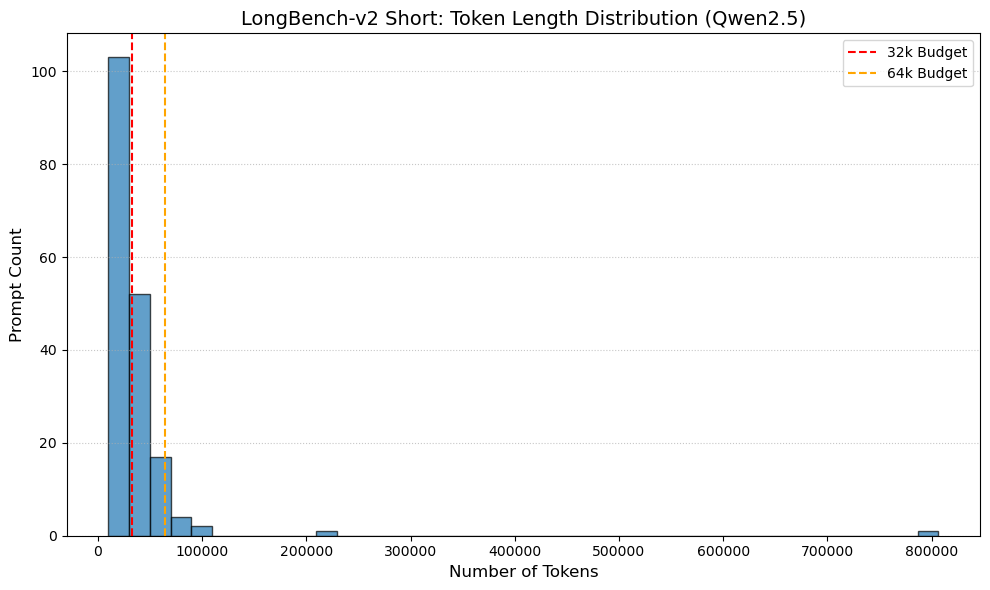

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import AutoTokenizer

# 1. Load the pinned Qwen tokenizer snapshot
MODEL_ID = "Qwen/Qwen2.5-7B-Instruct"
REVISION = "a09a35458c702b33eeacc393d103063234e8bc28"

print("Loading tokenizer and dataset...")
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_ID,
    revision=REVISION,
    trust_remote_code=True
)

dataset = load_dataset("MrBigBrane/longbench-v2-short", split="train")

# 2. Compute exact token lengths
lengths = []
for row in dataset:
    text = row.get("input") or row.get("inputs")
    token_count = len(tokenizer.encode(text, add_special_tokens=False))
    lengths.append(token_count)

lengths = np.array(lengths)

# 3. Print a quick ASCII Histogram in the terminal
print("\n=== ASCII Token Length Histogram ===")
# Define 8 bins focusing on reasonable context windows, plus outliers
bin_edges = [0, 8192, 16384, 24576, 32768, 49152, 65536, 131072, int(lengths.max()) + 1]
counts, _ = np.histogram(lengths, bins=bin_edges)

max_count = max(counts) if max(counts) > 0 else 1
for i in range(len(counts)):
    low = bin_edges[i]
    high = bin_edges[i + 1]
    cnt = counts[i]
    pct = (cnt / len(lengths)) * 100
    bar = "█" * int((cnt / max_count) * 40)
    print(f"[{low:6d} - {high:7d}): {bar:<40} {cnt:3d} ({pct:5.1f}%)")

# 4. Save a high-resolution graphical histogram (plot.png)
plt.figure(figsize=(10, 6))

# Plot histogram with a cutoff view or logarithmic bins if outliers are huge
plt.hist(lengths, bins=40, color="#1f77b4", edgecolor="black", alpha=0.7)
plt.axvline(32768, color="red", linestyle="--", linewidth=1.5, label="32k Budget")
plt.axvline(64000, color="orange", linestyle="--", linewidth=1.5, label="64k Budget")

plt.title("LongBench-v2 Short: Token Length Distribution (Qwen2.5)", fontsize=14)
plt.xlabel("Number of Tokens", fontsize=12)
plt.ylabel("Prompt Count", fontsize=12)
plt.grid(axis="y", linestyle=":", alpha=0.7)
plt.legend()
plt.tight_layout()

output_file = "token_length_histogram.png"
plt.savefig(output_file, dpi=300)
print(f"\nGraphical plot saved to {output_file}")

Loading Qwen tokenizer...
Loading THUDM/LongBench-v2 dataset...


Filter: 100%|██████████| 503/503 [00:00<00:00, 1165.23 examples/s]



==================== MEDIUM SUBSET (215 prompts) ====================


Tokenizing medium: 100%|██████████| 215/215 [01:09<00:00,  3.10it/s]



Summary for medium:
  Min:    42,078 tokens
  Median: 119,998 tokens
  Mean:   136,773 tokens
  Max:    548,388 tokens

ASCII Histogram (medium):
[  20,000 -   32,768):                                            0 (  0.0%)
[  32,768 -   48,000): █                                          2 (  0.9%)
[  48,000 -   65,536): ██████                                    11 (  5.1%)
[  65,536 -   96,000): █████████████████████████                 44 ( 20.5%)
[  96,000 -  131,072): ████████████████████████████████████████  69 ( 32.1%)
[ 131,072 -  180,000): ███████████████████████████████           54 ( 25.1%)
[ 180,000 -  250,000): █████████████                             23 ( 10.7%)
[ 250,000 -  500,000): ██████                                    11 (  5.1%)
Plot saved to token_hist_medium.png


Filter: 100%|██████████| 503/503 [00:00<00:00, 887.72 examples/s]



==================== LONG SUBSET (108 prompts) ====================


Tokenizing long: 100%|██████████| 108/108 [05:13<00:00,  2.90s/it]



Summary for long:
  Min:    167,276 tokens
  Median: 462,013 tokens
  Mean:   880,672 tokens
  Max:    4,163,955 tokens

ASCII Histogram (long):
[ 100,000 -  131,072):                                            0 (  0.0%)
[ 131,072 -  250,000): █████████████████████                     20 ( 18.5%)
[ 250,000 -  500,000): ████████████████████████████████████████  37 ( 34.3%)
[ 500,000 - 1,000,000): ███████████████████                       18 ( 16.7%)
[1,000,000 - 1,500,000): ████████████████                          15 ( 13.9%)
[1,500,000 - 2,000,000): ██████                                     6 (  5.6%)
[2,000,000 - 3,000,000): ████                                       4 (  3.7%)
Plot saved to token_hist_long.png


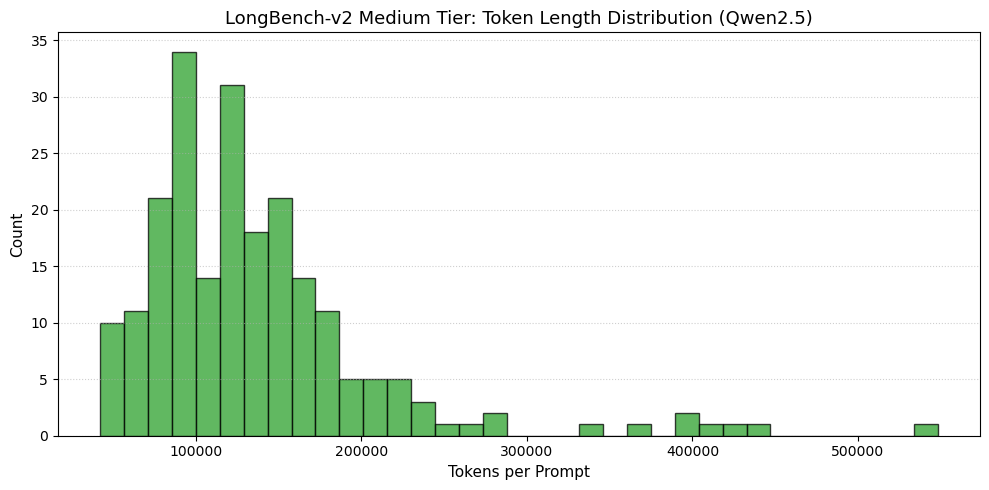

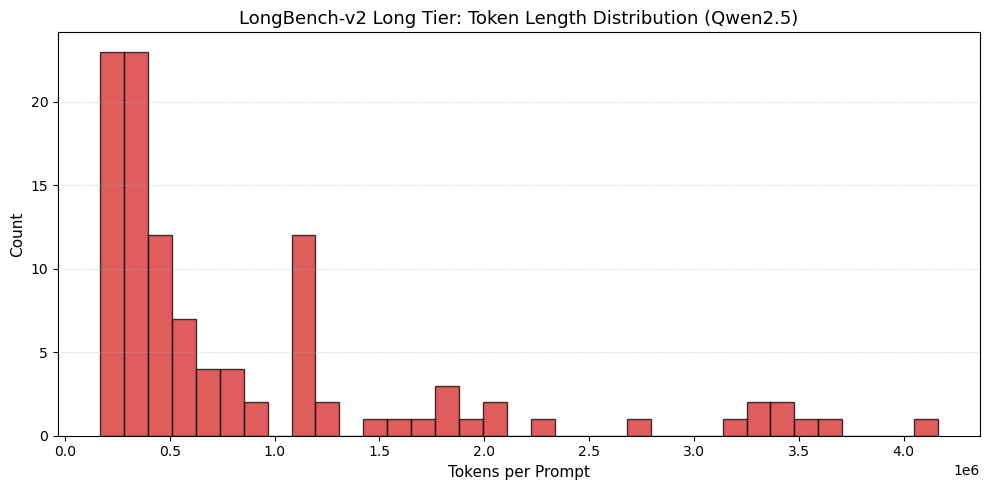

In [5]:
from datasets import load_dataset
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from transformers import AutoTokenizer

# 1. Pinned Qwen checkpoint and tokenizer
MODEL_ID = "Qwen/Qwen2.5-7B-Instruct"
REVISION = "a09a35458c702b33eeacc393d103063234e8bc28"

print("Loading Qwen tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_ID, revision=REVISION, trust_remote_code=True
)

# 2. Load original LongBench-v2 dataset
print("Loading THUDM/LongBench-v2 dataset...")
raw_ds = load_dataset("THUDM/LongBench-v2", split="train")

NEW_INSTRUCTION_SUFFIX = (
    "\n\nKeep your reasoning concise (under 3 sentences). "
    "There is exactly one correct option. "
    "On the final line, provide your answer in the exact format: "
    "'Final Answer: [X]' where X is a single letter (A, B, C, or D)."
)


def compute_token_length(example):
    user_content = (
        f"{example['context']}\n\n"
        f"Question: {example['question']}\n"
        f"A. {example['choice_A']}\n"
        f"B. {example['choice_B']}\n"
        f"C. {example['choice_C']}\n"
        f"D. {example['choice_D']}"
        f"{NEW_INSTRUCTION_SUFFIX}"
    )
    formatted = tokenizer.apply_chat_template(
        [{"role": "user", "content": user_content}],
        tokenize=False,
        add_generation_prompt=True,
    )
    # Tokenize directly to measure exact token length
    return len(tokenizer.encode(formatted, add_special_tokens=False))


def analyze_tier(tier_name, bin_edges, color, filename):
    subset = raw_ds.filter(lambda x: x["length"] == tier_name)
    print(
        f"\n==================== {tier_name.upper()} SUBSET ({len(subset)} prompts) ===================="
    )

    lengths = []
    for sample in tqdm(subset, desc=f"Tokenizing {tier_name}"):
        lengths.append(compute_token_length(sample))
    lengths = np.array(lengths)

    # Print summary metrics
    print(f"\nSummary for {tier_name}:")
    print(f"  Min:    {lengths.min():,d} tokens")
    print(f"  Median: {int(np.median(lengths)):,d} tokens")
    print(f"  Mean:   {int(lengths.mean()):,d} tokens")
    print(f"  Max:    {lengths.max():,d} tokens")

    # ASCII Histogram
    print(f"\nASCII Histogram ({tier_name}):")
    counts, _ = np.histogram(lengths, bins=bin_edges)
    max_count = max(counts) if max(counts) > 0 else 1

    for i in range(len(counts)):
        low = bin_edges[i]
        high = bin_edges[i + 1]
        cnt = counts[i]
        pct = (cnt / len(lengths)) * 100
        bar = "█" * int((cnt / max_count) * 40)
        print(f"[{low:8,d} - {high:8,d}): {bar:<40} {cnt:3d} ({pct:5.1f}%)")

    # Graphical Plot
    plt.figure(figsize=(10, 5))
    plt.hist(lengths, bins=35, color=color, edgecolor="black", alpha=0.75)
    plt.title(
        f"LongBench-v2 {tier_name.capitalize()} Tier: Token Length Distribution (Qwen2.5)",
        fontsize=13,
    )
    plt.xlabel("Tokens per Prompt", fontsize=11)
    plt.ylabel("Count", fontsize=11)
    plt.grid(axis="y", linestyle=":", alpha=0.6)
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    print(f"Plot saved to {filename}")


# 3. Process Medium Tier (~32k to 128k words; 215 samples)
medium_bins = [
    20000,
    32768,
    48000,
    65536,
    96000,
    131072,
    180000,
    250000,
    500000,
]
analyze_tier(
    tier_name="medium",
    bin_edges=medium_bins,
    color="#2ca02c",  # Green
    filename="token_hist_medium.png",
)

# 4. Process Long Tier (~128k to 2M words; 108 samples)
long_bins = [
    100000,
    131072,
    250000,
    500000,
    1000000,
    1500000,
    2000000,
    3000000,
]
analyze_tier(
    tier_name="long",
    bin_edges=long_bins,
    color="#d62728",  # Red
    filename="token_hist_long.png",
)

In [6]:
import os
from datasets import Dataset, Features, Value, load_dataset
from huggingface_hub import HfApi
from tqdm import tqdm
from transformers import AutoTokenizer

# 1. Exact model snapshot pinned by santapp-ruler
MODEL_ID = "Qwen/Qwen2.5-7B-Instruct"
REVISION = "a09a35458c702b33eeacc393d103063234e8bc28"

print(f"Loading tokenizer for {MODEL_ID}...")
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_ID, revision=REVISION, trust_remote_code=True
)

# Target context limits: 32768 total context - 256 generation headroom
TARGET_MAX_TOKENS = 32768
GEN_HEADROOM = 256
MAX_PROMPT_BUDGET = TARGET_MAX_TOKENS - GEN_HEADROOM  # 32,512 tokens

# Load complete LongBench-v2 benchmark (503 samples across all tiers)
print("Loading THUDM/LongBench-v2...")
raw_ds = load_dataset("THUDM/LongBench-v2", split="train")

NEW_INSTRUCTION_SUFFIX = (
    "\n\nKeep your reasoning concise (under 3 sentences). "
    "There is exactly one correct option. "
    "On the final line, provide your answer in the exact format: "
    "'Final Answer: [X]' where X is a single letter (A, B, C, or D)."
)


def middle_truncate_example(example):
    # Question and multiple-choice options block
    query_and_choices = (
        f"Question: {example['question']}\n"
        f"A. {example['choice_A']}\n"
        f"B. {example['choice_B']}\n"
        f"C. {example['choice_C']}\n"
        f"D. {example['choice_D']}"
        f"{NEW_INSTRUCTION_SUFFIX}"
    )

    # 1. Measure tokens taken by query, framing, and chat template tokens
    dummy_turn = f"{query_and_choices}"
    templated_dummy = tokenizer.apply_chat_template(
        [{"role": "user", "content": dummy_turn}],
        tokenize=True,
        add_generation_prompt=True,
    )
    framing_budget = len(templated_dummy)

    # Available token budget for the document context alone
    allowed_context_tokens = MAX_PROMPT_BUDGET - framing_budget

    # 2. Tokenize context document
    context_tokens = tokenizer.encode(
        example["context"], add_special_tokens=False
    )

    # 3. Apply middle truncation if context exceeds the available budget
    if len(context_tokens) > allowed_context_tokens:
        half = allowed_context_tokens // 2
        # Head segment + Tail segment
        truncated_ids = context_tokens[:half] + context_tokens[-half:]
        truncated_context_str = (
            tokenizer.decode(truncated_ids[:half])
            + "\n\n[... Middle content truncated to fit 32k context budget ...]\n\n"
            + tokenizer.decode(truncated_ids[half:])
        )
    else:
        truncated_context_str = example["context"]

    # 4. Assemble final user message and render through Qwen chat template
    full_user_turn = f"{truncated_context_str}\n\n{query_and_choices}"
    rendered_chat_input = tokenizer.apply_chat_template(
        [{"role": "user", "content": full_user_turn}],
        tokenize=False,
        add_generation_prompt=True,
    )

    return {
        "domain": str(example.get("domain", "unknown")),
        "sub_domain": str(example.get("sub_domain", "unknown")),
        "difficulty": str(example.get("difficulty", "unknown")),
        "input": rendered_chat_input,
        "output": str(example["answer"]).strip(),
    }


print(
    f"Processing and middle-truncating {len(raw_ds)} prompts to <= {MAX_PROMPT_BUDGET} tokens..."
)
processed_rows = [
    middle_truncate_example(row)
    for row in tqdm(raw_ds, desc="Middle Truncating")
]

# Enforce clean singular schema
features = Features(
    {
        "domain": Value("string"),
        "sub_domain": Value("string"),
        "difficulty": Value("string"),
        "input": Value("string"),
        "output": Value("string"),
    }
)
truncated_ds = Dataset.from_list(processed_rows, features=features)

# 5. Push to Hugging Face
REPO_ID = "MrBigBrane/longbench-v2-32k"
api = HfApi()

try:
    api.delete_file(
        path_in_repo="README.md",
        repo_id=REPO_ID,
        repo_type="dataset",
        commit_message="Wipe stale card metadata",
    )
except Exception:
    pass

# truncated_ds.push_to_hub(
#     repo_id=REPO_ID,
#     config_name="default",
#     split="train",
#     commit_message="Add 32k middle-truncated LongBench-v2 dataset",
# )

truncated_ds.push_to_hub(
    repo_id=REPO_ID,
    config_name="longbench-short",
    split="train",
    commit_message="Add longbench-short alias config for harness resolution",
)

print(
    f"Successfully uploaded {len(truncated_ds)} prompts to https://huggingface.co/datasets/{REPO_ID}"
)

Loading tokenizer for Qwen/Qwen2.5-7B-Instruct...
Loading THUDM/LongBench-v2...
Processing and middle-truncating 503 prompts to <= 32512 tokens...


Middle Truncating: 100%|██████████| 503/503 [04:39<00:00,  1.80it/s]
Setting num_proc from 1 back to 1 for the train split to disable multiprocessing as it only contains one shard.
Creating parquet from Arrow format: 100%|██████████| 1/1 [00:00<00:00,  7.69ba/s]
Processing Files (1 / 1): 100%|██████████| 26.9MB / 26.9MB, 1.69MB/s  
New Data Upload: 100%|██████████| 26.9MB / 26.9MB, 1.69MB/s  
Uploading the dataset shards: 100%|██████████| 1/1 [00:08<00:00,  8.23s/ shards]


Successfully uploaded 503 prompts to https://huggingface.co/datasets/MrBigBrane/longbench-v2-32k


Loading tokenizer: Qwen/Qwen2.5-7B-Instruct (rev: a09a3545)...
Loading dataset: MrBigBrane/longbench-v2-32k (longbench-short)...


Generating train split: 100%|██████████| 503/503 [00:00<00:00, 4554.49 examples/s]


Tokenizing 503 prompts...


Map: 100%|██████████| 503/503 [00:04<00:00, 106.08 examples/s]



Dataset: MrBigBrane/longbench-v2-32k (503 total prompts)
  Min tokens:    10,182
  25th %-tile:   32,644
  Median (50%):  32,701
  Mean:          30,184
  75th %-tile:   32,812
  95th %-tile:   33,018
  Max tokens:    36,195

=== ASCII Distribution ===
[     0 -  4,096):                                       0 (  0.0%)
[ 4,096 -  8,192):                                       0 (  0.0%)
[ 8,192 - 16,384): ████                                 27 (  5.4%)
[16,384 - 24,576): ███████                              46 (  9.1%)
[24,576 - 32,000): ███████                              43 (  8.5%)
[32,000 - 32,512):                                       0 (  0.0%)
[32,512 - 32,768): ███████████████████████████████████ 212 ( 42.1%)
[32,768 - 36,196): ████████████████████████████        175 ( 34.8%)

Saved histogram plot to: c:\Users\theep\OPUS Lab Notebooks\plotting\token_distribution_32k.png


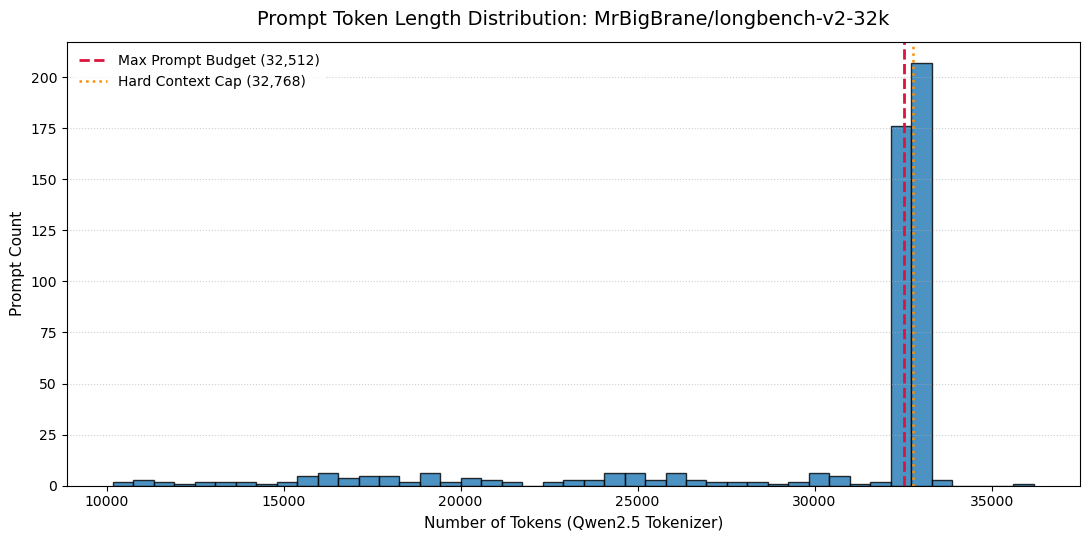

In [8]:
import os
from datasets import load_dataset
import matplotlib.pyplot as plt
import numpy as np
from transformers import AutoTokenizer

# 1. Target dataset and model configuration
DATASET_ID = "MrBigBrane/longbench-v2-32k"
DATASET_CONFIG = "longbench-short"  # Changed from "default"
SPLIT = "train"

MODEL_ID = "Qwen/Qwen2.5-7B-Instruct"
REVISION = "a09a35458c702b33eeacc393d103063234e8bc28"

print(f"Loading tokenizer: {MODEL_ID} (rev: {REVISION[:8]})...")
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_ID, revision=REVISION, trust_remote_code=True
)

print(f"Loading dataset: {DATASET_ID} ({DATASET_CONFIG})...")
dataset = load_dataset(DATASET_ID, name=DATASET_CONFIG, split=SPLIT)


# 2. Extract token lengths using batched mapping
def compute_lengths(batch):
    # Detect whether prompt column is stored as 'input' or 'inputs'
    prompts = batch.get("input") or batch.get("inputs")
    # Fast Rust-backed tokenization without allocating full input_ids tensors
    encodings = tokenizer(
        prompts, add_special_tokens=False, truncation=False, return_attention_mask=False
    )
    return {"token_count": [len(ids) for ids in encodings["input_ids"]]}


print(f"Tokenizing {len(dataset)} prompts...")
# Batched processing leverages Rust tokenizers for near-instant execution
mapped_ds = dataset.map(
    compute_lengths, batched=True, batch_size=100, remove_columns=dataset.column_names
)
token_counts = np.array(mapped_ds["token_count"])

# 3. Print statistical breakdown
print("\n" + "=" * 45)
print(f"Dataset: {DATASET_ID} ({len(token_counts)} total prompts)")
print(f"  Min tokens:    {token_counts.min():,d}")
print(f"  25th %-tile:   {int(np.percentile(token_counts, 25)):,d}")
print(f"  Median (50%):  {int(np.median(token_counts)):,d}")
print(f"  Mean:          {int(token_counts.mean()):,d}")
print(f"  75th %-tile:   {int(np.percentile(token_counts, 75)):,d}")
print(f"  95th %-tile:   {int(np.percentile(token_counts, 95)):,d}")
print(f"  Max tokens:    {token_counts.max():,d}")
print("=" * 45)

# 4. Terminal ASCII Histogram
print("\n=== ASCII Distribution ===")
bins = [0, 4096, 8192, 16384, 24576, 32000, 32512, 32768, int(token_counts.max()) + 1]
counts, edges = np.histogram(token_counts, bins=bins)
max_c = max(counts) if max(counts) > 0 else 1

for i in range(len(counts)):
    low, high = edges[i], edges[i + 1]
    cnt = counts[i]
    pct = (cnt / len(token_counts)) * 100
    bar = "█" * int((cnt / max_c) * 35)
    print(f"[{low:6,d} - {high:6,d}): {bar:<35} {cnt:3d} ({pct:5.1f}%)")

# 5. Graphical Matplotlib Histogram
plt.figure(figsize=(11, 5.5))
n, bin_edges, patches = plt.hist(
    token_counts, bins=45, color="#1f77b4", edgecolor="black", alpha=0.8
)

# Reference boundary lines
plt.axvline(
    32512,
    color="crimson",
    linestyle="--",
    linewidth=2,
    label="Max Prompt Budget (32,512)",
)
plt.axvline(
    32768,
    color="darkorange",
    linestyle=":",
    linewidth=1.8,
    label="Hard Context Cap (32,768)",
)

plt.title(f"Prompt Token Length Distribution: {DATASET_ID}", fontsize=14, pad=12)
plt.xlabel("Number of Tokens (Qwen2.5 Tokenizer)", fontsize=11)
plt.ylabel("Prompt Count", fontsize=11)
plt.grid(axis="y", linestyle=":", alpha=0.6)
plt.legend(frameon=True, facecolor="white", edgecolor="none")
plt.tight_layout()

out_plot = "token_distribution_32k.png"
plt.savefig(out_plot, dpi=300)
print(f"\nSaved histogram plot to: {os.path.abspath(out_plot)}")

In [ ]:
import numpy as np

# Find the index of the largest prompt
max_idx = int(np.argmax(token_counts))
sample = dataset[max_idx]
prompt_text = sample.get("input") or sample.get("inputs")

print(f"Max token count: {token_counts[max_idx]}")
print(f"Index: {max_idx}")
print(f"First 200 chars:\n{prompt_text[:200]}")
print(f"\nLast 200 chars:\n{prompt_text[-200:]}")

# Check if a truncation marker exists in the text
has_marker = (
    "[..." in prompt_text or "truncated" in prompt_text.lower() or "..." in prompt_text
)
print(f"\nContains truncation marker: {has_marker}")

Max token count: 36195
Index: 297
First 200 chars:
<|im_start|>system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant.<|im_end|>
<|im_start|>user
Comparative Analyses with
GAMS
Once a model is
completed, it is
almost always
used to

Last 200 chars:
nces). There is exactly one correct option. On the final line, provide your answer in the exact format: 'Final Answer: [X]' where X is a single letter (A, B, C, or D).<|im_end|>
<|im_start|>assistant


Contains truncation marker: True


: 